In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams,ticker,gridspec
import random
import time
from IPython.display import clear_output
from sklearn.neighbors import KernelDensity
import glob
import seaborn as sns
from astropy import units as u
from astropy.coordinates import SkyCoord
import multiprocessing
import collections
from shapely.geometry import Point
from matplotlib.path import Path
import colorcet as cc
from itertools import chain

#below for netflow
from __future__ import print_function
import ets_fiber_assigner.netflow as nf
from ics.cobraOps.Bench import Bench
from ics.cobraOps.TargetGroup import TargetGroup
from ics.cobraOps.CobrasCalibrationProduct import CobrasCalibrationProduct
from ics.cobraOps.CollisionSimulator import CollisionSimulator
from ics.cobraOps.cobraConstants import NULL_TARGET_POSITION, NULL_TARGET_ID
from ics.cobraOps import plotUtils
from collections import defaultdict

# read samples and KDE part

In [50]:
def readSamples(direc,Print):
    '''Read samples from the files: 
    in format of #ID, #RA, #DEC, #exposure, #length, #SciencePriority, #ScienceRank, #note

    Parameters
    ==========
    direc : string
        the name of directory containing sample lists

    Returns
    =======
    list of targets
    '''
    dir_=glob.glob(direc+'/*')
    if len(dir_)==0:
        dir_=[direc]
    allSamp=[]
    conA=0
    conB=0
    conC=0
    for l in dir_:
        temp=np.loadtxt(l,dtype='str')
        # convert rank: rankA=3, rankB=2, rankC=1 (currently Calib=0)
        if temp[0,4]=='A':
            rank=3
            rank_t='A'+str(conA+1)
            conA+=1
        elif temp[0,4]=='B':
            rank=2
            rank_t='B'+str(conB+1)
            conB+=1
        elif temp[0,4]=='C':
            rank=1
            rank_t='C'+str(conC+1)
            conC+=1
        #else:rank=0
        if Print==True:print(l,rank_t,rank)
        for i in temp:
            ID,ra,dec,exp,leng=i[0],float(i[1]),float(i[2]),float(i[3]),len(temp)                
            # currently one exposure set to be 900 sec.   
            allSamp.append([ID,ra,dec,exp/900.,leng,rank,rank_t,"ref"])  
    return np.array(allSamp, dtype="O") 

def readUserSample(direc,Print):
    sample_ref=readSamples('reference_s/',False)
    samp=[name for name,con in collections.Counter(sample_ref.T[-2]).items()]
    conA,conB,conC=[len([1 for tt in samp if tt[0]==ww]) for ww in ['A','B','C']]
    dir_=glob.glob(direc+'/*')
    if len(dir_)==0:
        dir_=[direc]
    usrSampRA=[qq for qq in sample_ref]
    usrSampRB=[qq for qq in sample_ref]
    usrSampRC=[qq for qq in sample_ref]
    usrSampCla=[]
    for l in range(len(dir_)):
        rank_t_ra='A'+str(int(conA+1+l))
        rank_t_rb='B'+str(int(conB+1+l))
        rank_t_rc='C'+str(int(conC+1+l))
        rank_t_cla='A'+str(int(l+1))
        temp=np.loadtxt(dir_[l],dtype='str')
        for i in temp:
            ID,ra,dec,exp,leng=i[0],float(i[1]),float(i[2]),float(i[3]),len(temp)
            usrSampRA.append([ID,ra,dec,exp/900.,leng,3,rank_t_ra,"usr"])  
            usrSampRB.append([ID,ra,dec,exp/900.,leng,2,rank_t_rb,"usr"])  
            usrSampRC.append([ID,ra,dec,exp/900.,leng,1,rank_t_rc,"usr"])  
            usrSampCla.append([ID,ra,dec,exp/900.,leng,3,rank_t_cla,"usr"])  
        if Print==True:print(dir_[l],"Your sample is:"+rank_t_ra+", "+rank_t_rb+", "+rank_t_rc+", "+rank_t_cla)
        print("####---------Read in samples done!")
    return np.array(usrSampRA, dtype="O"),np.array(usrSampRB, dtype="O") ,np.array(usrSampRC, dtype="O") ,np.array(usrSampCla, dtype="O")

def weight(sample,conta,contb,contc): 
    '''calculate weights of targets

    Parameters
    ==========
    Sample_t : array
        list of targets (ra,dec,exp,leng,rank,note)
    conta,contb: float
        parameters of weighting scheme-- conta>0, contb should be negative

    Returns
    =======
    list of weights
    '''
    rank=sample.T[5]
    leng_class=collections.Counter(sample.T[6])
    leng=np.array([leng_class[ee] for ee in sample.T[6]])
    time_remain=sample.T[3]

    wei=pow(conta,rank)*pow(time_remain,contb)*pow(leng,contc)
    return wei

def PFS_FoV_plot(raP,decP,PA,line_color,line_width,line_st):
    center=SkyCoord(raP*u.deg,decP*u.deg)
    #PA=0 along y-axis, PA=90 along x-axis, PA=180 along -y-axis...
    hexagon=center.directional_offset_by([30+PA,90+PA,150+PA,210+PA,270+PA,330+PA,30+PA]*u.deg,1.38/2.*u.deg)
    ra_h=hexagon.ra.deg
    dec_h=hexagon.dec.deg
    ra_h_in=np.where(np.fabs(ra_h-np.median(ra_h))>10)
    if len(ra_h_in[0])>0:
        if ra_h[ra_h_in[0][0]]>350:ra_h[ra_h_in[0][0]]-=360
        elif ra_h[ra_h_in[0][0]]<10:ra_h[ra_h_in[0][0]]+=360
    plt.plot(ra_h,dec_h,color=line_color,lw=line_width,ls=line_st)

def PFS_FoV(ra,dec,PA,sample):
    point=np.vstack((sample.T[1],sample.T[2])).T.astype('float')
    center=SkyCoord(ra*u.deg,dec*u.deg)
    #PA=0 along y-axis, PA=90 along x-axis, PA=180 along -y-axis...
    hexagon=center.directional_offset_by([30+PA,90+PA,150+PA,210+PA,270+PA,330+PA,30+PA]*u.deg,1.38/2.*u.deg)
    ra_h=hexagon.ra.deg
    dec_h=hexagon.dec.deg
    ra_h_in=np.where(np.fabs(ra_h-np.median(ra_h))>10)
    if len(ra_h_in[0])>0:
        if ra_h[ra_h_in[0][0]]>350:ra_h[ra_h_in[0][0]]-=360
        elif ra_h[ra_h_in[0][0]]<10:ra_h[ra_h_in[0][0]]+=360
    polygon = Path([(ra_h[t],dec_h[t]) for t in range(len(ra_h))])
    index_=np.where(polygon.contains_points(point)==True)[0]
    return index_

def test_KDE_xy(sample):
    values = np.vstack((np.deg2rad(sample.T[1].astype(float)),np.deg2rad(sample.T[2].astype(float))))
    kde = KernelDensity(bandwidth=np.deg2rad(1.38/2.), kernel='tophat',algorithm='ball_tree',metric='haversine')
    weights=sample.T[-1].astype(float)
    kde.fit(values.T,sample_weight=weights)
    X_, Y_ = np.mgrid[0:360:361j, -10:60:71j]
    X1=np.deg2rad(X_)
    Y1=np.deg2rad(Y_)
    positions = np.vstack([X1.ravel(), Y1.ravel()])    
    Z = np.reshape(np.exp(kde.score_samples(positions.T)), X_.shape)
    return Z

def KDE(sample):
    '''calculate KDE

    Parameters
    ==========
    Sample_t: array
        array of targets

    Returns
    =======
    ra_bin, dec_bin, significance of KDE over the field, ra of peak in KDE, dec of peak in KDE
    '''
    X_, Y_ = np.mgrid[0:360:361j, -10:60:71j] 
    positions = np.vstack([X_.ravel(), Y_.ravel()])
    with multiprocessing.Pool(20) as p:
        eee_=p.map(test_KDE_xy, np.array_split(sample, 20))
    Z=sum(eee_)
    
    #calculate significance level instead of direct KDE 
    obj_dis_sig_=(Z-np.mean(Z))/np.std(Z)
    #search for the peak of KDE as pointing center
    peak_x=positions[0,int(70*np.where(obj_dis_sig_==obj_dis_sig_.max())[0][0])]
    peak_y=positions[1,np.where(obj_dis_sig_==obj_dis_sig_.max())[1][0]]
    return X_,Y_,obj_dis_sig_,peak_x,peak_y

def KDE_plot(samp,sample_te,X_,Y_,obj_dis_sig_,peak_x,peak_y,sampling_r1,sampling_tot,fib_effi_tot):
    rcParams['figure.figsize'] = 15,10
    palette = sns.color_palette(cc.glasbey_warm, len(samp))
    plt.subplot(2, 1, 1)
    for o in range(len(samp)):
        plt.plot([sample_te[rr,1] for rr in range(len(sample_te)) if sample_te[rr][-2]==samp[o]],\
                    [sample_te[rr,2] for rr in range(len(sample_te)) if sample_te[rr][-2]==samp[o]],\
                        'o',mfc=palette[o],mec='none',ms=1)
    plt.contour(X_,Y_,obj_dis_sig_,20,vmin=-1.5,vmax=3,cmap='rainbow')
    PFS_FoV_plot(peak_x,peak_y,0,'k',1.5,'-')
    plt.text(0.5,50,s='Pointing'+str(ii),fontsize=20,bbox=dict(facecolor='white', edgecolor='none'))
    plt.xlabel('RA',fontsize=17)
    plt.ylabel('DEC',fontsize=17)
    plt.xticks(fontsize=17)
    plt.yticks(fontsize=17)
    plt.xlim(0,360)
    plt.ylim(-10,60)
    
    plt.subplot(2, 3, 4)
    for o in range(len(samp)):
        plt.bar(np.arange(1,len(samp)+1,1)[o],sampling_r1[o],width=0.9,fc=palette[o],ec='none')
    plt.plot([-10,100],[0.8,0.8],'k--',lw=2)
    plt.xlabel('sample',fontsize=17)
    plt.ylabel('sampling rate',fontsize=17)
    plt.yticks(fontsize=17)
    plt.xlim(0,18)
    plt.xticks(np.arange(1,17,1),samp,fontsize=12)
    plt.ylim(0,1.1)
    
    plt.subplot(2, 3, 5)
    plt.plot(np.arange(1,len(sampling_tot)+1,1),[ww[0] for ww in sampling_tot],'r-',lw=3)
    plt.plot(np.arange(1,len(sampling_tot)+1,1),[ww[1] for ww in sampling_tot],'c-',lw=2)
    plt.plot(np.arange(1,len(sampling_tot)+1,1),[ww[2] for ww in sampling_tot],'b-',lw=1)
    plt.xlabel('pointing',fontsize=17)
    plt.ylabel('sampling rate',fontsize=17)
    plt.yticks(fontsize=17)
    plt.xticks(fontsize=17)
    plt.xlim(0,len(sampling_tot)+1)
    plt.ylim(0,1.1)
    
    plt.subplot(2, 3, 6)
    plt.bar(np.arange(1,len(fib_effi_tot)+1,1),fib_effi_tot,width=0.8,fc='k',ec='none')
    plt.xlabel('pointing',fontsize=17)
    plt.ylabel('fiber efficiency',fontsize=17)
    plt.yticks(fontsize=17)
    plt.xticks(fontsize=17)
    plt.xlim(0,len(sampling_tot)+1)
    plt.ylim(0,1.1)
    #plt.savefig('/home/wanqiu/Dropbox/PFS_framework/test/'+str(ii)+'.jpg',bbox_inches='tight',dpi=300)
    plt.show()
        
def KDE_peak(sample_,plot,Npoint,Print):
    samp=[name for name,con in collections.Counter(sample_.T[-2]).items()]
    samp.sort()
    Nfiber=int(2394*0.7)
    sampling_full=np.array([collections.Counter(sample_.T[-2])[ee] for ee in samp])
    Na,Nb,Nc=[sum([collections.Counter(sample_.T[-2])[ee] for ee in samp if ee[0]==ww]) for ww in ['A','B','C']]

    ii=0
    peak=[]
    sampling=[0]*len(samp)
    sampling_ABC=[]
    fib_effi=[]
    sample_s=np.array([uu for uu in sample_])
    while ii<Npoint:
        #sum(sampling_r[:7])/Na<0.6:
        sample_te=np.array([np.append(sample_s[ooo],ooo) for ooo in range(len(sample_s)) if sample_s[ooo,3]>0])
        weight_te=weight(sample_te,10,-0.1,-0.02)
        Sample_t=np.array([np.append(sample_te[uu],weight_te[uu]) for uu in range(len(weight_te))])
        #-------------------------------
        ####peak_xy from KDE peaks
        X_,Y_,obj_dis_sig_,peak_x,peak_y=KDE(Sample_t)
        ####peak_xy from random object positions
        #ittt=np.random.choice(np.arange(0,len(Sample_t),1))
        #peak_x,peak_y=Sample_t[ittt][1],Sample_t[ittt][2]
        ####peak_xy from random object positions with weights
        #ittt=random.choices(np.arange(0,len(Sample_t),1),weights=weight_te.astype(float),k=1)
        #peak_x,peak_y=Sample_t[ittt[0]][1],Sample_t[ittt[0]][2]
        ####peak_xy from uniform distribution
        #peak_x=2*ii -360*int(ii/180)
        #peak_y=-10+2*int(ii/180)
        #-------------------------------
        index_1=PFS_FoV(peak_x,peak_y,0,Sample_t)
        ##move to a nearby grid if the peak contains 0 object
        while len(index_1)==0:
            peak_x=peak_x+np.random.choice([2,1,-1,-2,0])
            peak_y=peak_y+np.random.choice([2,1,-1,-2,0])
            index_1=PFS_FoV(peak_x,peak_y,0,Sample_t)
        peak.append([peak_x,peak_y])
        index_=Sample_t.T[-2][index_1]
        
        if len(index_)>Nfiber:
            ttt=random.sample(list(index_), Nfiber)
            sample_s[ttt,3]-=1
        else:
            sample_s[list(index_),3]-=1
        ii+=1
    
        #check sampling & efficiency------------------------------
        sampling+=np.array([len([1 for rr in list(index_) if sample_s[rr,-2]==samp[o] and sample_s[rr,3]==0]) \
                    for o in range(len(samp))])
        sampling_r=sampling/sampling_full
        sampling_r[np.isnan(sampling_r)]=0
        sampling_rABC=[sum([sampling[ee] for ee in range(len(samp)) if samp[ee][0]==ww]) for ww in ['A','B','C']]
        if Na*Nb*Nc!=0 and Print==True:
            sampling_ABC.append([sampling_rABC[0]/Na,sampling_rABC[1]/Nb,sampling_rABC[2]/Nc])
            print(str(ii),len(index_),len(sample_te),peak_x,peak_y, "RankA=","{:2.2f}%".format(100*sampling_rABC[0]/Na),\
              ", RankB=","{:2.2f}%".format(100*sampling_rABC[1]/Nb),\
              ", RankC=","{:2.2f}%".format(100*sampling_rABC[2]/Nc))
        elif Print==True:
            sampling_ABC.append([sampling_rABC[0]/Na,0,0])
            print(str(ii),len(index_),len(sample_te),peak_x,peak_y, "RankA=","{:2.2f}%".format(100*sampling_rABC[0]/Na),\
              ", RankB=","{:2.2f}%".format(999),\
              ", RankC=","{:2.2f}%".format(999))
        
        fib_effi1=len(index_)/2394.
        if fib_effi1>1:fib_effi1=1
        fib_effi.append(fib_effi1)
            
        #plot
        if plot==False:continue
        else:
            clear_output(wait=True)
            KDE_plot(samp,sample_te,X_,Y_,obj_dis_sig_,peak_x,peak_y,sampling_r,sampling_ABC,fib_effi)
    print("####---------Determine KDE peaks done!")
    return peak,sampling_r,sampling_ABC,fib_effi,sample_s

# netflow part

In [51]:
def sam2netflow(sample,prefix):######!!!!!!!!!need consider F-star later
    res=[]
    weight_te=weight(sample,10,-0.1,-0.02)
    for tt in sample:
        id_, ra, dec, tm, pri = (tt[0], float(tt[1]), float(tt[2]),float(tt[3])*900.0, tt[6])
        res.append(nf.ScienceTarget(id_, ra, dec, tm, pri, prefix))
    return res

def NetflowPreparation(sample):######!!!!!!!!!need consider F-star later
    samp=[name for name,con in collections.Counter(sample.T[-2]).items()]
    samp.sort()
    #all_samp=np.array([collections.Counter(sample.T[-2])[ee] for ee in samp])
    weight_tem=weight(sample,10,-0.1,-0.02)
    weight_t=np.array([[samp[ii],weight_tem[np.where(sample.T[-2]==samp[ii])[0]][0]] for ii in range(len(samp))])
    classdict = {}
    for yy in range(len(weight_t)):
        classdict["sci_P"+weight_t[yy,0]] = {"nonObservationCost": float(weight_t[yy,1]),
                           "partialObservationCost": float(weight_t[yy,1])*1.5, "calib": False}
    return classdict,weight_t

def netflowRun(Pointing,sample,t_obs,posang,nvisit,gurobiPa):
    bench = Bench(layout="full")
    tgt=sam2netflow(sample,'sci')
    classdict,weight_t=NetflowPreparation(sample)
    Telra=[Pointing[yy] for yy in range(len(Pointing)) if yy%2==0]
    Teldec=[Pointing[yy] for yy in range(len(Pointing)) if yy%2!=0]
    otime = "2016-04-03T08:00:00Z"
    telescopes = []
    
    for kk in range(min(nvisit,len(Telra))):
        telescopes.append(nf.Telescope(Telra[kk], Teldec[kk], posang, otime))
    tpos = [tele.get_fp_positions(tgt) for tele in telescopes]

    # optional: slightly increase the cost for later observations,
    # to observe as early as possible
    vis_cost = [1 for i in range(nvisit)]

    # optional: penalize assignments where the cobra has to move far out
    def cobraMoveCost(dist):
        return 0.1*dist

    gurobiOptions = gurobiPa

    # partially observed? no
    alreadyObserved={}

    # compute observation strategy
    prob = nf.buildProblem(bench, tgt, tpos, classdict, t_obs,
                       vis_cost, cobraMoveCost=cobraMoveCost,
                       collision_distance=2., elbow_collisions=True,
                       gurobi=True, gurobiOptions=gurobiOptions,
                       alreadyObserved=alreadyObserved)

    #print("solving the problem")
    prob.solve()
    Obj=prob._prob.objVal

    # extract solution
    res = [{} for _ in range(min(nvisit,len(Telra)))]
    for k1, v1 in prob._vardict.items():
        if k1.startswith("Tv_Cv_"):
            visited = prob.value(v1) > 0
            if visited:
                _, _, tidx, cidx, ivis = k1.split("_")
                res[int(ivis)][int(tidx)] = int(cidx)

    #print fiber assign
    fib_eff=[]        #fiber efficiency
    obj_allo=[]
    for i, (vis, tp, tel) in enumerate(zip(res, tpos, telescopes)):
        print("exposure {}:".format(i))
        print("  assigned Cobras: {}".format(len(vis)))
        print("  assigned Cobras(%): {:.2f}%".format(len(vis)/2394.*100))
        fib_eff.append(len(vis)/2394.*100)
        tdict = defaultdict(int)
        for tidx, cidx in vis.items():
            #print (tidx,cidx)
            tdict[tgt[tidx].targetclass] += 1
            obj_allo.append(["Point"+str(i+1), tel._ra, tel._dec, tel._posang,tgt[tidx].ID,
                             cidx+1, tp[tidx].real, tp[tidx].imag,tgt[tidx].ra, tgt[tidx].dec,
                             tgt[tidx].targetclass[5:]])
    sample_=np.array([uu for uu in sample])
    for qq in range(len(obj_allo)):
        sample_.T[3][np.where(sample_.T[0]==obj_allo[qq][4])[0]]-=1
    print("####---------Run netflow done!")
    return fib_eff,Obj,obj_allo,sample_#'''   

# test

In [52]:
def output(sampp,Npoint):
    peak,sampling_r,sampling_ABC,fib_effi,sample_s=KDE_peak(sampp,False,Npoint,False)
    gurobiPa=dict(seed=0, presolve=1, method=0, degenmoves=0,heuristics=0.6, mipfocus=0, mipgap=5.0e-2)#,LogToConsole=0)
    fib_eff,Obj,obj_allo,sample__=netflowRun(list(chain.from_iterable(peak)),sampp,900,0,Npoint,gurobiPa)
    sampD,sampU,sampP=[len([1 for ii in range(len(sample__)) if sample__[ii][3]<=0 and sample__[ii][-1]=='usr']),\
                    len([1 for ii in range(len(sample__)) if sample__[ii][3]==sampp[ii][3] and sample__[ii][-1]=='usr']),\
                    len([1 for ii in range(len(sample__)) if sample__[ii][3]<sampp[ii][3] and sample__[ii][3]>0 \
                         and sample__[ii][-1]=='usr'])]
    return sampD,sampU,sampP,sampD+sampU+sampP,sample__,obj_allo,fib_eff

In [53]:
%%time
sampleRA,sampleRB,sampleRC,sampleCla=readUserSample('user_s/',True)

#insert number of pointing here:
npoint=100

#ourput: complete fraction, no-taken fraction, partly observed fraction, sum of previous three, output sample, output list of allocation, fiber allocation efficiency 
doneA,undoneA,partA,totA,sampleRA_fin,samp_alloA,fibA=output(sampleRA,npoint)
doneB,undoneB,partB,totB,sampleRB_fin,samp_alloB,fibB=output(sampleRB,npoint)
doneC,undoneC,partC,totC,sampleRC_fin,samp_alloC,fibC=output(sampleRC,npoint)
doneCla,undoneCla,partCla,totCla,sampleCla_fin,samp_alloCla,fibCla=output(sampleCla,npoint)

user_s/z4qso Your sample is:A7, B8, C3, A1
####---------Read in samples done!
####---------Determine KDE peaks done!
Parameter seed unchanged
   Value: 0  Min: 0  Max: 2000000000  Default: 0
Changed value of parameter presolve to 1
   Prev: -1  Min: -1  Max: 2  Default: -1
Changed value of parameter method to 0
   Prev: -1  Min: -1  Max: 5  Default: -1
Changed value of parameter degenmoves to 0
   Prev: -1  Min: -1  Max: 2000000000  Default: -1
Changed value of parameter heuristics to 0.6
   Prev: 0.05  Min: 0.0  Max: 1.0  Default: 0.05
Parameter mipfocus unchanged
   Value: 0  Min: 0  Max: 3  Default: 0
Changed value of parameter mipgap to 0.05
   Prev: 0.0001  Min: 0.0  Max: inf  Default: 0.0001
Creating network topology
  exposure 1
Calculating visibilities
adding constraints
adding collision constraints
  exposure 2
Calculating visibilities
adding constraints
adding collision constraints
  exposure 3
Calculating visibilities
adding constraints
adding collision constraints
  exposur

adding constraints
adding collision constraints
  exposure 88
Calculating visibilities
adding constraints
adding collision constraints
  exposure 89
Calculating visibilities
adding constraints
adding collision constraints
  exposure 90
Calculating visibilities
adding constraints
adding collision constraints
  exposure 91
Calculating visibilities
adding constraints
adding collision constraints
  exposure 92
Calculating visibilities
adding constraints
adding collision constraints
  exposure 93
Calculating visibilities
adding constraints
adding collision constraints
  exposure 94
Calculating visibilities
adding constraints
adding collision constraints
  exposure 95
Calculating visibilities
adding constraints
adding collision constraints
  exposure 96
Calculating visibilities
adding constraints
adding collision constraints
  exposure 97
Calculating visibilities
adding constraints
adding collision constraints
  exposure 98
Calculating visibilities
adding constraints
adding collision constra

####---------Run netflow done!
####---------Determine KDE peaks done!
Parameter seed unchanged
   Value: 0  Min: 0  Max: 2000000000  Default: 0
Changed value of parameter presolve to 1
   Prev: -1  Min: -1  Max: 2  Default: -1
Changed value of parameter method to 0
   Prev: -1  Min: -1  Max: 5  Default: -1
Changed value of parameter degenmoves to 0
   Prev: -1  Min: -1  Max: 2000000000  Default: -1
Changed value of parameter heuristics to 0.6
   Prev: 0.05  Min: 0.0  Max: 1.0  Default: 0.05
Parameter mipfocus unchanged
   Value: 0  Min: 0  Max: 3  Default: 0
Changed value of parameter mipgap to 0.05
   Prev: 0.0001  Min: 0.0  Max: inf  Default: 0.0001
Creating network topology
  exposure 1
Calculating visibilities
adding constraints
adding collision constraints
  exposure 2
Calculating visibilities
adding constraints
adding collision constraints
  exposure 3
Calculating visibilities
adding constraints
adding collision constraints
  exposure 4
Calculating visibilities
adding constraints

adding constraints
adding collision constraints
  exposure 88
Calculating visibilities
adding constraints
adding collision constraints
  exposure 89
Calculating visibilities
adding constraints
adding collision constraints
  exposure 90
Calculating visibilities
adding constraints
adding collision constraints
  exposure 91
Calculating visibilities
adding constraints
adding collision constraints
  exposure 92
Calculating visibilities
adding constraints
adding collision constraints
  exposure 93
Calculating visibilities
adding constraints
adding collision constraints
  exposure 94
Calculating visibilities
adding constraints
adding collision constraints
  exposure 95
Calculating visibilities
adding constraints
adding collision constraints
  exposure 96
Calculating visibilities
adding constraints
adding collision constraints
  exposure 97
Calculating visibilities
adding constraints
adding collision constraints
  exposure 98
Calculating visibilities
adding constraints
adding collision constra

####---------Run netflow done!
####---------Determine KDE peaks done!
Parameter seed unchanged
   Value: 0  Min: 0  Max: 2000000000  Default: 0
Changed value of parameter presolve to 1
   Prev: -1  Min: -1  Max: 2  Default: -1
Changed value of parameter method to 0
   Prev: -1  Min: -1  Max: 5  Default: -1
Changed value of parameter degenmoves to 0
   Prev: -1  Min: -1  Max: 2000000000  Default: -1
Changed value of parameter heuristics to 0.6
   Prev: 0.05  Min: 0.0  Max: 1.0  Default: 0.05
Parameter mipfocus unchanged
   Value: 0  Min: 0  Max: 3  Default: 0
Changed value of parameter mipgap to 0.05
   Prev: 0.0001  Min: 0.0  Max: inf  Default: 0.0001
Creating network topology
  exposure 1
Calculating visibilities
adding constraints
adding collision constraints
  exposure 2
Calculating visibilities
adding constraints
adding collision constraints
  exposure 3
Calculating visibilities
adding constraints
adding collision constraints
  exposure 4
Calculating visibilities
adding constraints

adding constraints
adding collision constraints
  exposure 88
Calculating visibilities
adding constraints
adding collision constraints
  exposure 89
Calculating visibilities
adding constraints
adding collision constraints
  exposure 90
Calculating visibilities
adding constraints
adding collision constraints
  exposure 91
Calculating visibilities
adding constraints
adding collision constraints
  exposure 92
Calculating visibilities
adding constraints
adding collision constraints
  exposure 93
Calculating visibilities
adding constraints
adding collision constraints
  exposure 94
Calculating visibilities
adding constraints
adding collision constraints
  exposure 95
Calculating visibilities
adding constraints
adding collision constraints
  exposure 96
Calculating visibilities
adding constraints
adding collision constraints
  exposure 97
Calculating visibilities
adding constraints
adding collision constraints
  exposure 98
Calculating visibilities
adding constraints
adding collision constra

####---------Run netflow done!
####---------Determine KDE peaks done!
Parameter seed unchanged
   Value: 0  Min: 0  Max: 2000000000  Default: 0
Changed value of parameter presolve to 1
   Prev: -1  Min: -1  Max: 2  Default: -1
Changed value of parameter method to 0
   Prev: -1  Min: -1  Max: 5  Default: -1
Changed value of parameter degenmoves to 0
   Prev: -1  Min: -1  Max: 2000000000  Default: -1
Changed value of parameter heuristics to 0.6
   Prev: 0.05  Min: 0.0  Max: 1.0  Default: 0.05
Parameter mipfocus unchanged
   Value: 0  Min: 0  Max: 3  Default: 0
Changed value of parameter mipgap to 0.05
   Prev: 0.0001  Min: 0.0  Max: inf  Default: 0.0001
Creating network topology
  exposure 1
Calculating visibilities
adding constraints
adding collision constraints
  exposure 2
Calculating visibilities
adding constraints
adding collision constraints
  exposure 3
Calculating visibilities
adding constraints
adding collision constraints
  exposure 4
Calculating visibilities
adding constraints

adding constraints
adding collision constraints
  exposure 89
Calculating visibilities
adding constraints
adding collision constraints
  exposure 90
Calculating visibilities
adding constraints
adding collision constraints
  exposure 91
Calculating visibilities
adding constraints
adding collision constraints
  exposure 92
Calculating visibilities
adding constraints
adding collision constraints
  exposure 93
Calculating visibilities
adding constraints
adding collision constraints
  exposure 94
Calculating visibilities
adding constraints
adding collision constraints
  exposure 95
Calculating visibilities
adding constraints
adding collision constraints
  exposure 96
Calculating visibilities
adding constraints
adding collision constraints
  exposure 97
Calculating visibilities
adding constraints
adding collision constraints
  exposure 98
Calculating visibilities
adding constraints
adding collision constraints
  exposure 99
Calculating visibilities
adding constraints
adding collision constra

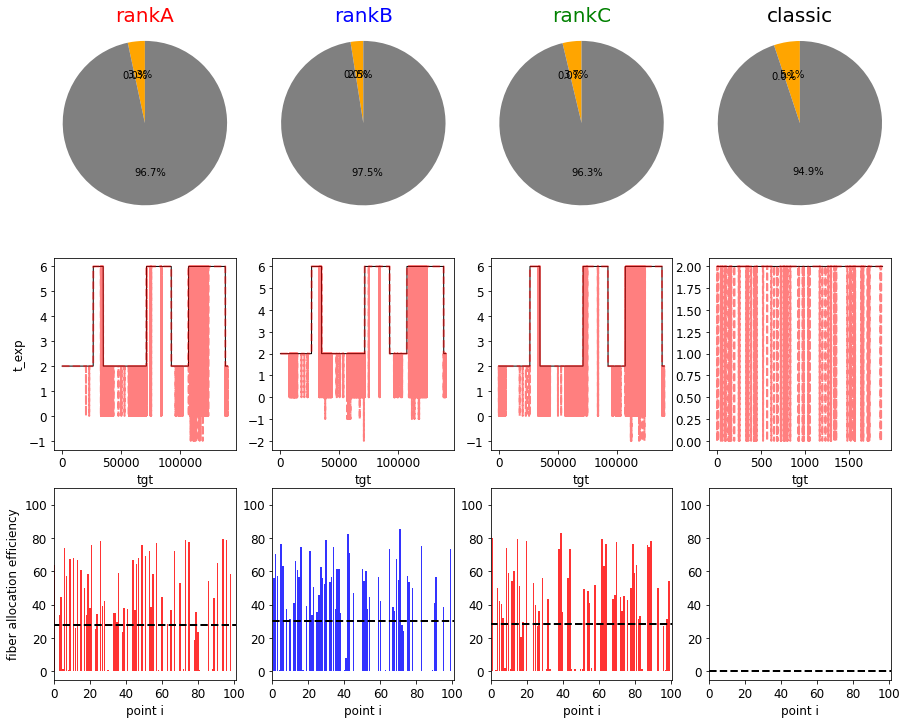

In [54]:
#plot results
rcParams['figure.figsize'] = 15,12
plt.subplot(3, 4, 1)
plt.pie([doneA/totA,partA/totA,undoneA/totA],autopct='%1.1f%%', startangle=90,colors=['orange','g','grey'],normalize=True)
plt.title('rankA',color='r',fontsize=20)
plt.axis('equal')

plt.subplot(3, 4, 2)
plt.pie([doneB/totB,partB/totB,undoneB/totB],autopct='%1.1f%%', startangle=90,colors=['orange','g','grey'],normalize=True)
plt.title('rankB',color='b',fontsize=20)
plt.axis('equal')

plt.subplot(3, 4, 3)
plt.pie([doneC/totC,partC/totC,undoneC/totC],autopct='%1.1f%%', startangle=90,colors=['orange','g','grey'],normalize=True)
plt.title('rankC',color='g',fontsize=20)
plt.axis('equal')

plt.subplot(3, 4, 4)
plt.pie([doneCla/totCla,partCla/totCla,undoneCla/totCla],autopct='%1.1f%%', startangle=90,colors=['orange','g','grey'],normalize=True)
plt.title('classic',color='k',fontsize=20)
plt.axis('equal')#'''

plt.subplot(3, 4, 5)
plt.plot(np.arange(len(sampleRA)),sampleRA.T[3],'k-',lw=1)
plt.plot(np.arange(len(sampleRA_fin)),sampleRA_fin.T[3],'r--',lw=2,alpha=0.5)
plt.xlabel('tgt',fontsize=12)
plt.ylabel('t_exp',fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.subplot(3, 4, 6)
plt.plot(np.arange(len(sampleRB)),sampleRB.T[3],'k-',lw=1)
plt.plot(np.arange(len(sampleRB_fin)),sampleRB_fin.T[3],'r--',lw=2,alpha=0.5)
plt.xlabel('tgt',fontsize=12)
#plt.ylabel('t_exp',fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.subplot(3, 4, 7)
plt.plot(np.arange(len(sampleRC)),sampleRC.T[3],'k-',lw=1)
plt.plot(np.arange(len(sampleRC_fin)),sampleRC_fin.T[3],'r--',lw=2,alpha=0.5)
plt.xlabel('tgt',fontsize=12)
#plt.ylabel('t_exp',fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.subplot(3, 4, 8)
plt.plot(np.arange(len(sampleCla)),sampleCla.T[3],'k-',lw=1)
plt.plot(np.arange(len(sampleCla_fin)),sampleCla_fin.T[3],'r--',lw=2,alpha=0.5)
plt.xlabel('tgt',fontsize=12)
#plt.ylabel('t_exp',fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.subplot(3, 4, 9)
plt.bar(np.arange(len(fibA)),fibA,width=0.8,fc='r',ec='none',alpha=0.8)
plt.plot([-100,1e10],[np.mean(fibA),np.mean(fibA)],'k--',lw=2)
plt.xlabel('point i',fontsize=12)
plt.ylabel('fiber allocation efficiency',fontsize=12)
plt.xlim(0,len(fibA)+1)
plt.ylim(-5,110)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.subplot(3, 4, 10)
plt.bar(np.arange(len(fibB)),fibB,width=0.8,fc='b',ec='none',alpha=0.8)
plt.plot([-100,1e10],[np.mean(fibB),np.mean(fibB)],'k--',lw=2)
plt.xlabel('point i',fontsize=12)
plt.xlim(0,len(fibB)+1)
plt.ylim(-5,110)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.subplot(3, 4, 11)
plt.bar(np.arange(len(fibC)),fibC,width=0.8,fc='r',ec='none',alpha=0.8)
plt.plot([-100,1e10],[np.mean(fibC),np.mean(fibC)],'k--',lw=2)
plt.xlabel('point i',fontsize=12)
plt.xlim(0,len(fibC)+1)
plt.ylim(-5,110)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.subplot(3, 4, 12)
plt.bar(np.arange(len(fibCla)),fibCla,width=0.8,fc='r',ec='none',alpha=0.8)
plt.plot([-100,1e10],[np.mean(fibCla),np.mean(fibCla)],'k--',lw=2)
plt.xlabel('point i',fontsize=12)
plt.xlim(0,len(fibCla)+1)
plt.ylim(-5,110)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()